# HB Smoke Fit User Guide And Observed-vs-Predicted Check

This helper notebook is for collaborators who want to use the current HB smoke-fit outputs without reading the full implementation notebook.

It answers:

```text
What files do I load?
What does each important column mean?
Do model-predicted distributions look similar to observed participant distributions?
```

This uses the smoke-fit outputs from `hb_verified_model_implementation.ipynb`.


In [1]:
# Cell purpose: Import libraries and load the saved smoke-fit outputs.

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIT_RESULTS_PATH = OUTPUT_DIR / "hb_verified_fit_results_smoke.csv"
TRIAL_PREDICTIONS_PATH = OUTPUT_DIR / "hb_verified_trial_predictions_smoke.csv"

fit_results = pd.read_csv(FIT_RESULTS_PATH)
trial_predictions = pd.read_csv(TRIAL_PREDICTIONS_PATH)

print("fit_results:", fit_results.shape, FIT_RESULTS_PATH)
print("trial_predictions:", trial_predictions.shape, TRIAL_PREDICTIONS_PATH)
display(fit_results.head())
display(trial_predictions.head())


fit_results: (12, 14) C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_verified_fit_results_smoke.csv
trial_predictions: (8640, 15) C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_verified_trial_predictions_smoke.csv


,subject_id,readout,n_trials_fit,nll,nll_per_trial,optimizer_success,optimizer_status,optimizer_message,carryover_weight,learning_tau,k_motor,lapse_rate,k_llh_by_coherence,k_prior_target_by_std
0,1,MAP,720,3362.004410,4.669451,True,0,Optimization terminated successfully.,0.027293,3.039263,11.986870,0.123385,"{""0.06"":3.7225888112336416,""0.12"":10.746463324...","{""10.0"":40.25496066545633,""20.0"":11.6525339620..."
1,2,MAP,720,3143.499885,4.365972,True,0,Optimization terminated successfully.,0.014483,6.502300,28.375734,0.135590,"{""0.06"":0.4872153969318228,""0.12"":0.4065966752...","{""10.0"":58.24423994820123,""20.0"":26.7020989899..."
2,3,MAP,720,3327.848900,4.622012,True,0,Optimization terminated successfully.,0.077474,12.961306,14.002142,0.131059,"{""0.06"":0.4829005160703099,""0.12"":9.9460078714...","{""10.0"":11.189010011551849,""20.0"":2.1118393618..."
3,4,MAP,720,3548.003648,4.927783,True,0,Optimization terminated successfully.,0.739985,3.272906,9.181374,0.178838,"{""0.06"":0.15138257838390312,""0.12"":36.35566791...","{""10.0"":0.13791496463676814,""20.0"":55.21202555..."
4,5,MAP,720,3872.231062,5.378099,True,0,Optimization terminated successfully.,0.057955,39.563985,3.211171,0.218654,"{""0.06"":17.4347028203165,""0.12"":42.65626292084...","{""10.0"":0.5458776576240003,""20.0"":0.1835205437..."


,subject_id,session_id,run_id,trial_index,motion_direction,estimate_deg,prior_mean,prior_std,motion_coherence,prior_kappa_t,predicted_estimate_deg,p_observed,predicted_error_from_motion,observed_error_from_motion,fit_readout
0,1,1,1,1,225.0,225.583113,225.0,10.0,0.12,40.254961,225.0,0.021233,0.0,0.583113,MAP
1,1,1,1,2,225.0,223.291282,225.0,10.0,0.12,40.254961,225.0,0.021135,0.0,-1.708718,MAP
2,1,1,1,3,235.0,231.312691,225.0,10.0,0.06,40.254961,226.0,0.020197,-9.0,-3.687309,MAP
3,1,1,1,4,225.0,230.166776,225.0,10.0,0.06,40.254961,225.0,0.020252,0.0,5.166776,MAP
4,1,1,1,5,215.0,229.020860,225.0,10.0,0.24,40.254961,222.0,0.019449,7.0,14.020860,MAP


## What The Two Files Mean

`hb_verified_fit_results_smoke.csv` has one row per subject.

Important columns:

```text
nll, nll_per_trial = model fit score; lower is better
k_llh_by_coherence = fitted sensory precision by motion coherence
k_prior_target_by_std = fitted prior confidence target by prior width
carryover_weight = how much previous-block confidence carries over
learning_tau = speed of within-block confidence learning
k_motor = response precision after readout
lapse_rate = random-response probability
```

`hb_verified_trial_predictions_smoke.csv` has one row per fitted trial.

Important columns:

```text
estimate_deg = participant response angle
predicted_estimate_deg = model's point prediction before motor noise/lapse
prior_kappa_t = fitted trial-level prior confidence
p_observed = probability assigned to the actual participant response
observed_error_from_motion = participant error
predicted_error_from_motion = model point-prediction error
```


In [2]:
# Cell purpose: Show a compact model-fit summary across subjects.

summary_cols = [
    "subject_id", "n_trials_fit", "nll_per_trial", "optimizer_success",
    "carryover_weight", "learning_tau", "k_motor", "lapse_rate",
]
fit_summary = fit_results[summary_cols].copy()
display(fit_summary)

print("Subjects fit:", fit_summary["subject_id"].nunique())
print("All optimizers reported success:", bool(fit_summary["optimizer_success"].all()))
print("Mean NLL per trial:", round(float(fit_summary["nll_per_trial"].mean()), 3))


,subject_id,n_trials_fit,nll_per_trial,optimizer_success,carryover_weight,learning_tau,k_motor,lapse_rate
0,1,720,4.669451,True,0.027293,3.039263,11.986870,0.123385
1,2,720,4.365972,True,0.014483,6.502300,28.375734,0.135590
2,3,720,4.622012,True,0.077474,12.961306,14.002142,0.131059
3,4,720,4.927783,True,0.739985,3.272906,9.181374,0.178838
4,5,720,5.378099,True,0.057955,39.563985,3.211171,0.218654
5,6,720,5.267399,True,0.051761,3.205668,3.879386,0.173737
6,7,720,4.803503,True,0.233031,39.531383,7.934748,0.107797
7,8,720,5.337648,True,0.832786,12.580174,4.785586,0.237129
8,9,720,5.052422,True,0.266557,3.543777,6.622954,0.180383
9,10,720,5.448903,True,0.315131,79.253287,3.397972,0.236054


Subjects fit: 12
All optimizers reported success: True
Mean NLL per trial: 5.012


In [3]:
# Cell purpose: Define circular helper functions and simulate model response samples from point predictions.

rng = np.random.default_rng(20260717)


def wrap_signed_deg(angle):
    return (np.asarray(angle) + 180.0) % 360.0 - 180.0


def simulate_model_responses(trial_df: pd.DataFrame, fit_df: pd.DataFrame, rng: np.random.Generator) -> pd.DataFrame:
    frames = []
    for subject_id, subject_trials in trial_df.groupby("subject_id", observed=True):
        fit_row = fit_df.loc[fit_df["subject_id"] == subject_id].iloc[0]
        k_motor = float(fit_row["k_motor"])
        lapse_rate = float(fit_row["lapse_rate"])
        predicted = subject_trials["predicted_estimate_deg"].to_numpy(dtype=float)
        is_lapse = rng.random(len(subject_trials)) < lapse_rate
        simulated = np.empty(len(subject_trials), dtype=float)
        simulated[is_lapse] = rng.uniform(0.0, 360.0, size=int(is_lapse.sum()))
        if (~is_lapse).any():
            simulated[~is_lapse] = np.degrees(
                rng.vonmises(mu=np.deg2rad(predicted[~is_lapse]), kappa=k_motor)
            ) % 360.0
        out = subject_trials.copy()
        out["model_simulated_estimate_deg"] = simulated
        out["model_simulated_error_from_motion"] = wrap_signed_deg(simulated - out["motion_direction"].to_numpy(dtype=float))
        out["model_simulated_is_lapse"] = is_lapse
        frames.append(out)
    return pd.concat(frames, ignore_index=True)

comparison_df = simulate_model_responses(trial_predictions, fit_results, rng)
comparison_path = OUTPUT_DIR / "hb_smoke_observed_predicted_distribution_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("saved:", comparison_path)
display(comparison_df.head())


saved: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_smoke_observed_predicted_distribution_comparison.csv


,subject_id,session_id,run_id,trial_index,motion_direction,estimate_deg,prior_mean,prior_std,motion_coherence,prior_kappa_t,predicted_estimate_deg,p_observed,predicted_error_from_motion,observed_error_from_motion,fit_readout,model_simulated_estimate_deg,model_simulated_error_from_motion,model_simulated_is_lapse
0,1,1,1,1,225.0,225.583113,225.0,10.0,0.12,40.254961,225.0,0.021233,0.0,0.583113,MAP,221.462315,-3.537685,False
1,1,1,1,2,225.0,223.291282,225.0,10.0,0.12,40.254961,225.0,0.021135,0.0,-1.708718,MAP,231.528590,6.528590,False
2,1,1,1,3,235.0,231.312691,225.0,10.0,0.06,40.254961,226.0,0.020197,-9.0,-3.687309,MAP,236.180248,1.180248,False
3,1,1,1,4,225.0,230.166776,225.0,10.0,0.06,40.254961,225.0,0.020252,0.0,5.166776,MAP,325.653429,100.653429,True
4,1,1,1,5,215.0,229.020860,225.0,10.0,0.24,40.254961,222.0,0.019449,7.0,14.020860,MAP,238.479391,23.479391,False


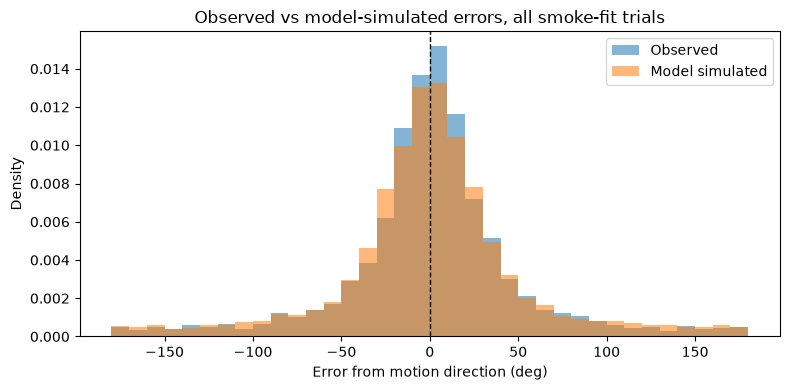

In [4]:
# Cell purpose: Compare observed and model-simulated error distributions overall.

bins = np.arange(-180, 181, 10)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(comparison_df["observed_error_from_motion"], bins=bins, density=True, alpha=0.55, label="Observed")
ax.hist(comparison_df["model_simulated_error_from_motion"], bins=bins, density=True, alpha=0.55, label="Model simulated")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Error from motion direction (deg)")
ax.set_ylabel("Density")
ax.set_title("Observed vs model-simulated errors, all smoke-fit trials")
ax.legend()
plt.tight_layout()
plt.show()


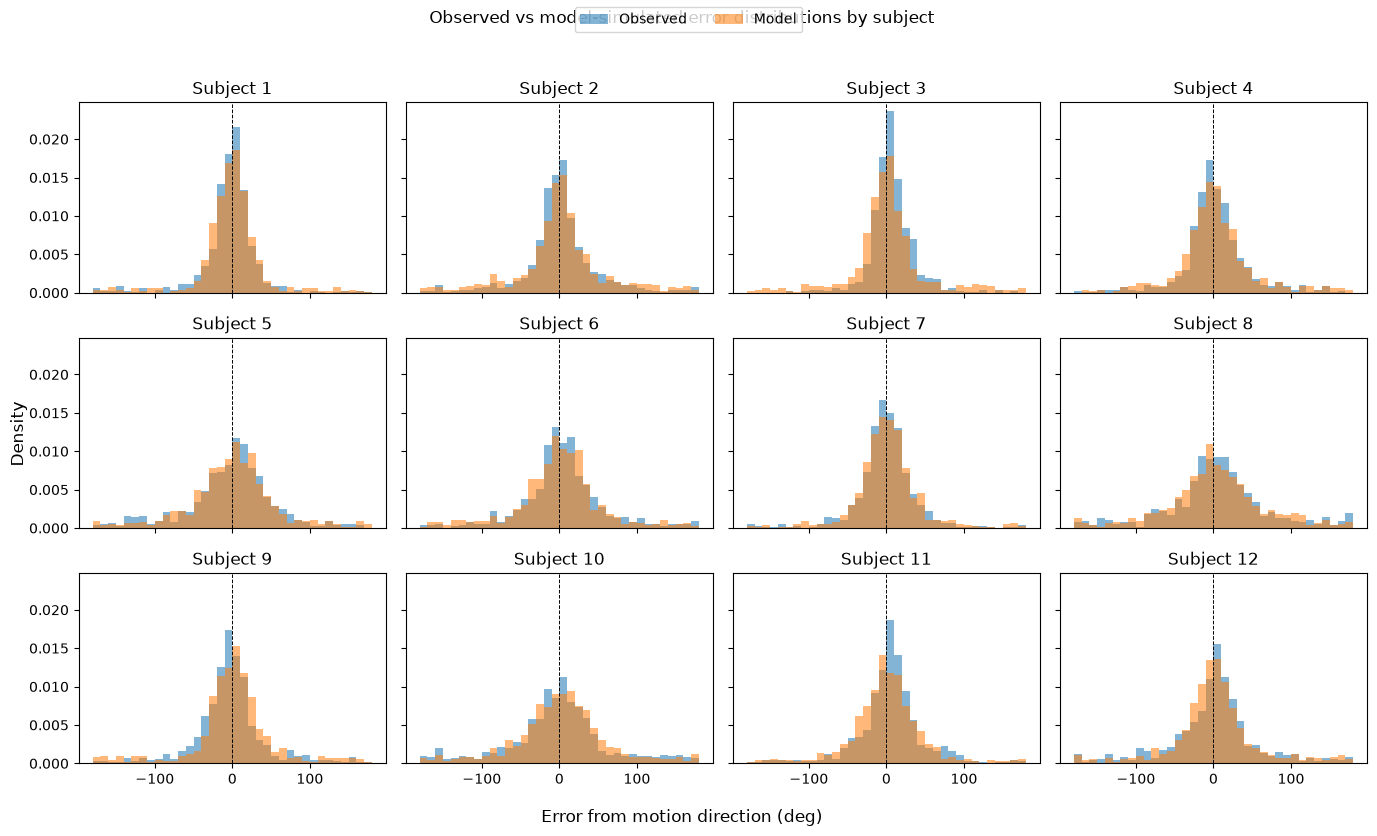

In [5]:
# Cell purpose: Compare observed and model-simulated error distributions by subject.

subject_ids = sorted(comparison_df["subject_id"].unique())
fig, axes = plt.subplots(3, 4, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, subject_id in zip(axes, subject_ids):
    d = comparison_df[comparison_df["subject_id"] == subject_id]
    ax.hist(d["observed_error_from_motion"], bins=bins, density=True, alpha=0.55, label="Observed")
    ax.hist(d["model_simulated_error_from_motion"], bins=bins, density=True, alpha=0.55, label="Model")
    ax.axvline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(f"Subject {subject_id}")
for ax in axes[len(subject_ids):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.supxlabel("Error from motion direction (deg)")
fig.supylabel("Density")
fig.suptitle("Observed vs model-simulated error distributions by subject", y=1.03)
plt.tight_layout()
plt.show()


In [6]:
# Cell purpose: Summarize observed-vs-model distribution differences using simple descriptive metrics.

comparison_summary = (
    comparison_df.groupby("subject_id", observed=True)
    .agg(
        n_trials=("trial_index", "size"),
        observed_mean_abs_error=("observed_error_from_motion", lambda x: float(np.mean(np.abs(x)))),
        model_mean_abs_error=("model_simulated_error_from_motion", lambda x: float(np.mean(np.abs(x)))),
        observed_error_sd=("observed_error_from_motion", "std"),
        model_error_sd=("model_simulated_error_from_motion", "std"),
        mean_prior_confidence=("prior_kappa_t", "mean"),
        mean_p_observed=("p_observed", "mean"),
    )
    .reset_index()
)
comparison_summary["abs_error_difference_model_minus_observed"] = (
    comparison_summary["model_mean_abs_error"] - comparison_summary["observed_mean_abs_error"]
)
comparison_summary_path = OUTPUT_DIR / "hb_smoke_observed_predicted_distribution_summary.csv"
comparison_summary.to_csv(comparison_summary_path, index=False)
print("saved:", comparison_summary_path)
display(comparison_summary)


saved: C:\Users\HP\Desktop\nxkvtrj9ps-1\nxkvtrj9ps-1\outputs\hb_smoke_observed_predicted_distribution_summary.csv


,subject_id,n_trials,observed_mean_abs_error,model_mean_abs_error,observed_error_sd,model_error_sd,mean_prior_confidence,mean_p_observed,abs_error_difference_model_minus_observed
0,1,720,23.207177,25.736932,38.645630,42.624347,11.413988,0.013963,2.529755
1,2,720,31.071365,38.327920,48.325179,57.368334,19.835382,0.020965,7.256556
2,3,720,20.590494,31.454937,30.497821,49.885687,3.555173,0.014817,10.864443
3,4,720,29.233385,33.318786,44.295369,49.706523,12.582371,0.010849,4.085401
4,5,720,40.774318,40.821404,56.749079,57.513227,0.211263,0.006117,0.047086
5,6,720,36.958317,39.600442,53.699081,56.614575,13.968894,0.007179,2.642125
6,7,720,25.998119,28.741553,39.864358,43.261914,5.114081,0.011700,2.743433
7,8,720,47.375287,46.712795,66.460717,63.617737,25.658730,0.007007,-0.662492
8,9,720,30.012454,34.028304,45.109645,52.799088,3.536047,0.009349,4.015851
9,10,720,46.664794,43.420656,65.837344,60.369637,6.981690,0.006060,-3.244138


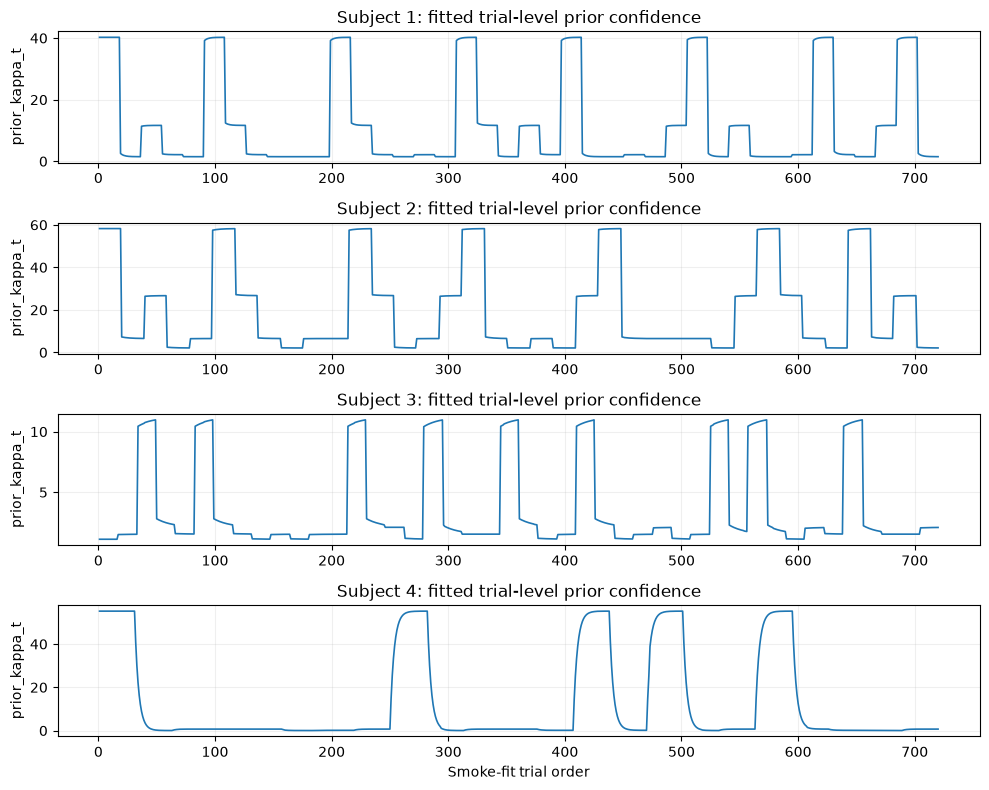

In [7]:
# Cell purpose: Plot prior-confidence trajectories for example subjects.

example_subjects = sorted(comparison_df["subject_id"].unique())[:4]
fig, axes = plt.subplots(len(example_subjects), 1, figsize=(10, 8), sharex=False)
if len(example_subjects) == 1:
    axes = [axes]
for ax, subject_id in zip(axes, example_subjects):
    d = comparison_df[comparison_df["subject_id"] == subject_id].copy().reset_index(drop=True)
    ax.plot(d.index + 1, d["prior_kappa_t"], linewidth=1.2)
    ax.set_title(f"Subject {subject_id}: fitted trial-level prior confidence")
    ax.set_ylabel("prior_kappa_t")
    ax.grid(True, alpha=0.2)
axes[-1].set_xlabel("Smoke-fit trial order")
plt.tight_layout()
plt.show()


## How To Interpret The Comparison

Use this notebook as a first visual check.

If observed and model-simulated histograms overlap well, the smoke fit is capturing the broad response-error distribution.

If they differ strongly, the model may need:

```text
full-trial fitting
more optimizer restarts
measurement-marginalized likelihood
better switching observer comparison
parameter recovery checks
```

This helper notebook is not final model validation. It is the first observed-vs-predicted distribution check for the smoke fit.
